In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cleaned tables
customers = pd.read_csv("customers_cleaned.csv")
billing = pd.read_csv("billing_cleaned.csv")
subscriptions = pd.read_csv("subscriptions_cleaned.csv")
payments = pd.read_csv("payments_cleaned.csv")

# Original tables
plans = pd.read_csv("plans.csv")
plan_history = pd.read_csv("plan_history.csv")
contracts = pd.read_csv("contracts.csv")
devices = pd.read_csv("devices.csv")
recharges = pd.read_csv("recharges.csv")
usage_voice = pd.read_csv("usage_voice.csv")
usage_sms = pd.read_csv("usage_sms.csv")
usage_data = pd.read_csv("usage_data.csv")
network_quality = pd.read_csv("network_quality.csv")
support_tickets = pd.read_csv("support_tickets.csv")
complaints = pd.read_csv("complaints.csv")
customer_feedback = pd.read_csv("customer_feedback.csv")
retention_campaigns = pd.read_csv("retention_campaigns.csv")
marketing_campaigns = pd.read_csv("marketing_campaigns.csv")
employees = pd.read_csv("employees.csv")
stores = pd.read_csv("stores.csv")
regions = pd.read_csv("regions.csv")
cities = pd.read_csv("cities.csv")
states = pd.read_csv("states.csv")
data_quality_issue_log = pd.read_csv("data_quality_issue_log.csv")

In [3]:
# Customers
customers["date_of_birth"] = pd.to_datetime(customers["date_of_birth"])
customers["acquisition_date"] = pd.to_datetime(customers["acquisition_date"])
customers["churn_date"] = pd.to_datetime(customers["churn_date"])

# Billing
billing["billing_date"] = pd.to_datetime(billing["billing_date"])
billing["due_date"] = pd.to_datetime(billing["due_date"])

# Complaints
complaints["complaint_date"] = pd.to_datetime(complaints["complaint_date"], format="%d-%m-%Y")
complaints["resolution_date"] = pd.to_datetime(complaints["resolution_date"], format="%d-%m-%Y")

# Contracts
contracts["start_date"] = pd.to_datetime(contracts["start_date"], format="%d-%m-%Y")
contracts["end_date"] = pd.to_datetime(contracts["end_date"], format="%d-%m-%Y")

# Customer Feedback
customer_feedback["feedback_date"] = pd.to_datetime(customer_feedback["feedback_date"], format="%d-%m-%Y")

# Payments
payments["payment_date"] = pd.to_datetime(payments["payment_date"])

# Devices
devices["purchase_date"] = pd.to_datetime(devices["purchase_date"], format="%d-%m-%Y")

# Employees
employees["hire_date"] = pd.to_datetime(employees["hire_date"], format="%d-%m-%Y")

# Marketing Campaigns
marketing_campaigns["start_date"] = pd.to_datetime(marketing_campaigns["start_date"], format="%d-%m-%Y")
marketing_campaigns["end_date"] = pd.to_datetime(marketing_campaigns["end_date"], format="%d-%m-%Y")

# Plan History
plan_history["change_date"] = pd.to_datetime(plan_history["change_date"], format="%d-%m-%Y")

# Recharges
recharges["recharge_date"] = pd.to_datetime(recharges["recharge_date"], format="%d-%m-%Y")

# Retention Campaigns
retention_campaigns["contact_date"] = pd.to_datetime(retention_campaigns["contact_date"], format="%d-%m-%Y")

# Subscriptions
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])

# Stores
stores["opened_date"] = pd.to_datetime(stores["opened_date"], format="%d-%m-%Y")

# Support Tickets
support_tickets["created_date"] = pd.to_datetime(support_tickets["created_date"], format="%d-%m-%Y")
support_tickets["resolution_date"] = pd.to_datetime(support_tickets["resolution_date"], format="%d-%m-%Y")

In [4]:
#Overall churn rate — a KPI card plus a bar chart of churned vs active customers.

In [5]:
churned_customers = customers[customers["customer_status"] == "Churned"]
Total_customers = customers["customer_status"].count()

churn_rate = round(len(churned_customers) / Total_customers*100,2)
print("Overall churn rate %:", churn_rate)

Overall churn rate %: 18.45


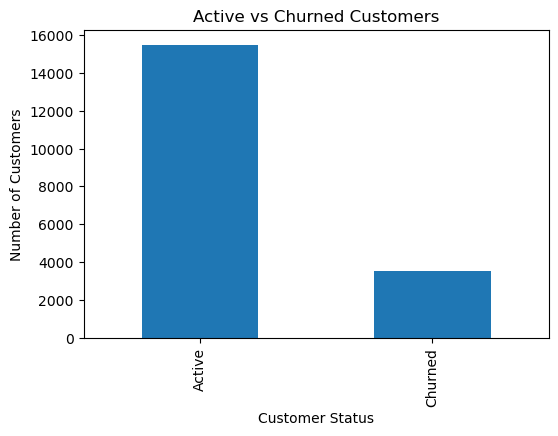

In [6]:
customer_status = customers["customer_status"].value_counts()
customer_status.plot(kind="bar",figsize=(6,4))
plt.title("Active vs Churned Customers")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.savefig("Chart1_Overall_Churn.png", dpi=300, bbox_inches="tight")

## Observation

- The overall customer churn rate is **18.45%**, indicating that approximately **1 in every 5 customers** has discontinued the service.
- Out of **19,000 total customers**, the **15494** majority remain active, while the churned customer **3506** represents a significant portion that requires further analysis.
- This overall churn rate serves as a baseline for identifying the key factors contributing to customer attrition in the subsequent analyses.

In [7]:
#Churn by billing cycle — compare Monthly vs Annual plans. Which churns more?

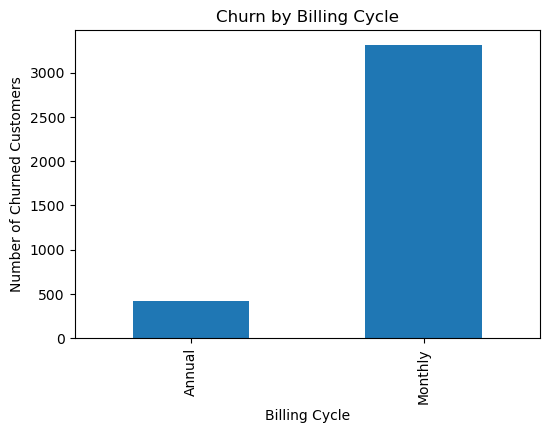

In [8]:
customer_subscription = pd.merge(customers, subscriptions, on="customer_id")

churn_billing = customer_subscription[customer_subscription["customer_status"] == "Churned"].groupby("billing_cycle")["customer_status"].count()

churn_billing.plot(kind="bar",figsize=(6,4))   
plt.title("Churn by Billing Cycle")
plt.xlabel("Billing Cycle")
plt.ylabel("Number of Churned Customers")
plt.savefig("Chart2_Churn_by_billing_cycle.png", dpi=300, bbox_inches="tight")

## Observation

- Customers with **Monthly** billing plans have a significantly higher churn compared to customers on **Annual** billing plans.
- Customers subscribed to **Annual** plans appear to be more loyal, indicating better customer retention through long-term subscriptions.
- This suggests that encouraging customers to switch from monthly to annual plans could help reduce overall churn.

In [9]:
#Churn by tenure band — a line or bar chart across 0-3m, 3-12m, 1-3y, 3y+.

C:\Users\mrnk1\AppData\Local\Temp\ipykernel_19168\1248800811.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_tenure = customers[customers["customer_status"] == "Churned"].groupby("tenure_band")["customer_status"].count()


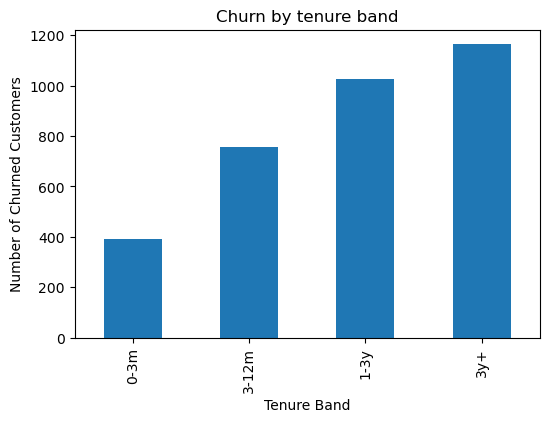

In [10]:
customers["tenure_band"] = pd.cut(customers["tenure_months"],bins=[0, 3, 12, 36, float("inf")],labels=["0-3m", "3-12m", "1-3y", "3y+"])

churn_tenure = customers[customers["customer_status"] == "Churned"].groupby("tenure_band")["customer_status"].count()

churn_tenure.plot(kind="bar",figsize=(6,4))   
plt.title("Churn by tenure band")
plt.xlabel("Tenure Band")
plt.ylabel("Number of Churned Customers")
plt.savefig("Chart3_Churn_by_tenure_band.png", dpi=300, bbox_inches="tight")

## Observation

- Customers in the **3y+** tenure band have the highest number of churns, followed by those in the **1–3 years** tenure band.
- The **0–3 months** tenure band has the lowest churn count, while churn gradually increases as customer tenure increases.
- This indicates that a larger number of long-tenure customers are churning, suggesting the need for targeted retention strategies for loyal customers.

In [11]:
#Churn by number of unresolved complaints — does churn rise with complaints?

In [12]:
complaint_count = complaints[complaints["status"] == "Unresolved"].groupby("customer_id").size().reset_index(name="unresolved_complaints")

In [13]:
customer_complaints = pd.merge(customers,complaint_count,on="customer_id",how="left")
customer_complaints["unresolved_complaints"] = customer_complaints["unresolved_complaints"].fillna(0)

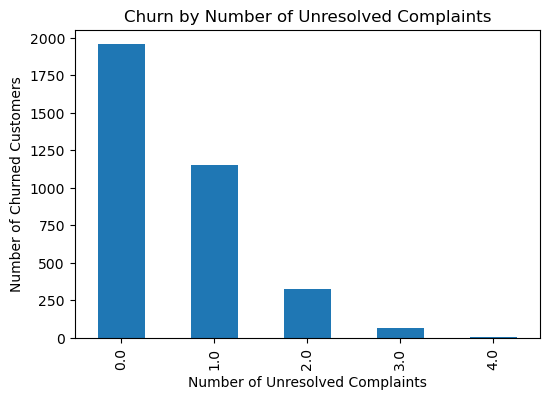

In [14]:
churn_complaints = customer_complaints[customer_complaints["customer_status"] == "Churned"].groupby("unresolved_complaints")["customer_status"].count()

churn_complaints.plot(kind="bar", figsize=(6,4))

plt.title("Churn by Number of Unresolved Complaints")
plt.xlabel("Number of Unresolved Complaints")
plt.ylabel("Number of Churned Customers")
plt.savefig("Chart4_Churn_by_Unresolved_Complaints.png", dpi=300, bbox_inches="tight")

## Observation

- Most churned customers had **no unresolved complaints**, while the number of churned customers decreases as the number of unresolved complaints increases.
- Only a small number of churned customers had **2 or more unresolved complaints**, with very few customers having 3 or 4 unresolved complaints.
- This suggests that unresolved complaints alone may not be the primary driver of churn, and other factors should also be analyzed to understand customer attrition.

In [15]:
#Churn by customer segment — Mass / Value / Premium / Enterprise.

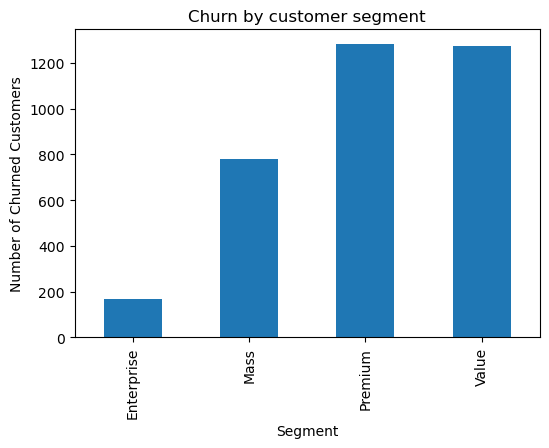

In [16]:
customer_plan = pd.merge(customers, plans, on="plan_id")

churn_segment = customer_plan[customer_plan["customer_status"] == "Churned"].groupby("segment")["customer_status"].count()

churn_segment.plot(kind="bar",figsize=(6,4))   
plt.title("Churn by customer segment")
plt.xlabel("Segment")
plt.ylabel("Number of Churned Customers")
plt.savefig("Chart5_Churn_by_customer_segment.png", dpi=300, bbox_inches="tight")

## Observation

- The **Premium** and **Value** customer segments have the highest number of churned customers, with both segments showing similar churn counts.
- The **Mass** segment has a moderate number of churned customers, while the **Enterprise** segment records the lowest churn count.
- These findings indicate that a larger number of churn cases are concentrated in the Premium and Value segments, making them important segments for further retention analysis.

In [17]:
#Top 10 states/circles by churned customers — a horizontal bar chart.

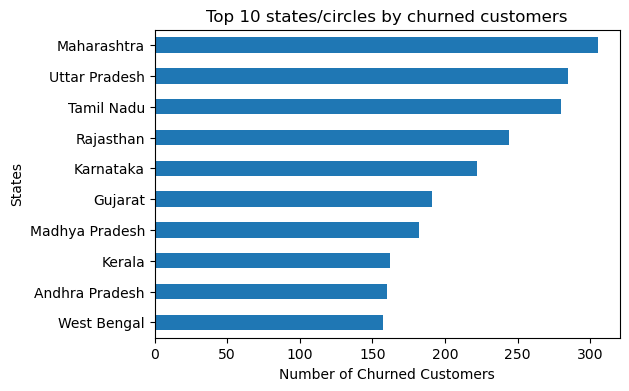

In [18]:
customer_states = pd.merge(customers, states, on="state_id")

churn_states = customer_states[customer_states["customer_status"] == "Churned"].groupby("state_name")["customer_status"].count()
churn_states_sorted = churn_states.sort_values(ascending=False).head(10)

churn_states_sorted.plot(kind="barh",figsize=(6,4))   
plt.title("Top 10 states/circles by churned customers")
plt.xlabel("Number of Churned Customers")
plt.ylabel("States")
plt.gca().invert_yaxis()
plt.savefig("Chart6_Top_10_states_by_churned_customers.png", dpi=300, bbox_inches="tight")

## Observation

- Maharashtra has the highest number of churned customers, followed by Uttar Pradesh and Tamil Nadu.
- Rajasthan and Karnataka also record a relatively high number of churned customers, while West Bengal, Andhra Pradesh, and Kerala have the lowest churn counts among the top 10 states.
- These findings indicate that customer churn is concentrated in a few key states, making them priority regions for targeted customer retention initiatives.

In [19]:
#Average data usage by city tier — Metro vs Tier-2 vs Tier-3 (histogram or bar).

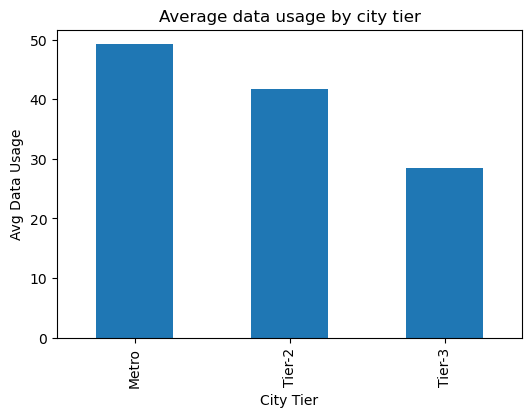

In [20]:
customer_usage_data = pd.merge(customers, usage_data, on="customer_id")

avg_usage_data_city_tier = customer_usage_data.groupby("city_tier")["data_gb_used"].mean()

avg_usage_data_city_tier.plot(kind="bar",figsize=(6,4))

plt.title("Average data usage by city tier")
plt.xlabel("City Tier")
plt.ylabel("Avg Data Usage")
plt.savefig("Chart7_Average_data_usage_by_city_tier.png", dpi=300, bbox_inches="tight")

## Observation

- Customers in **Metro** cities have the highest average data usage, followed by customers in **Tier-2** cities.
- **Tier-3** cities record the lowest average data usage among the three city tiers.
- This indicates that data consumption decreases from Metro to Tier-3 cities, suggesting differences in customer usage patterns across city tiers.

In [21]:
#ARPU distribution — a histogram of monthly charge across the base.

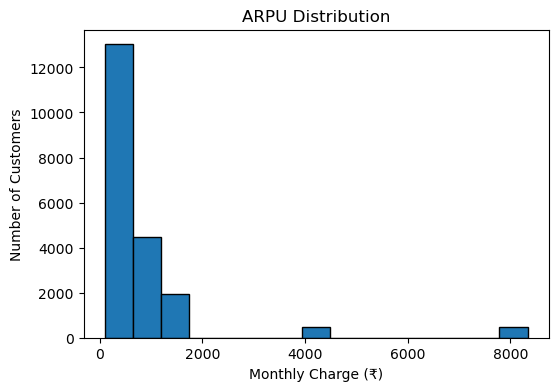

In [22]:
subscriptions["monthly_charge_inr"].plot(kind="hist",bins=15,figsize=(6,4),edgecolor="black")

plt.title("ARPU Distribution")
plt.xlabel("Monthly Charge (₹)")
plt.ylabel("Number of Customers")
plt.savefig("Chart8_ARPU_Distribution.png", dpi=300, bbox_inches="tight")

## Observation

- The ARPU distribution is concentrated in the lower monthly charge range, indicating that most customers subscribe to low- to mid-priced plans.
- Only a small proportion of customers are subscribed to premium plans with higher monthly charges, resulting in a right-skewed distribution.
- This suggests that the customer base is primarily composed of users on affordable plans, while high-value plans contribute a relatively smaller share of subscriptions.

In [23]:
#Network quality vs churn — scatter or grouped bar of dropped-call rate vs churn.

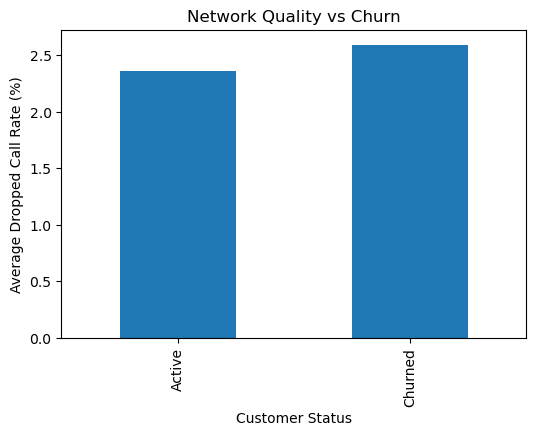

In [44]:
customer_network = pd.merge(customers, network_quality, on="customer_id")
avg_drop_rate = customer_network.groupby("customer_status")["dropped_call_rate_pct"].mean()

avg_drop_rate.plot(kind="bar", figsize=(6,4))

plt.title("Network Quality vs Churn")
plt.xlabel("Customer Status")
plt.ylabel("Average Dropped Call Rate (%)")
plt.savefig("Chart9_Network_Quality_vs_Churn.png", dpi=300, bbox_inches="tight")

## Observation

- Churned customers have a higher average dropped-call rate than active customers.
- This suggests that poorer network quality may be associated with increased customer churn.
- Improving network performance and reducing dropped calls could help enhance customer satisfaction and reduce churn.

In [209]:
#Retention campaign outcomes — accepted / declined / no response, and retained share.

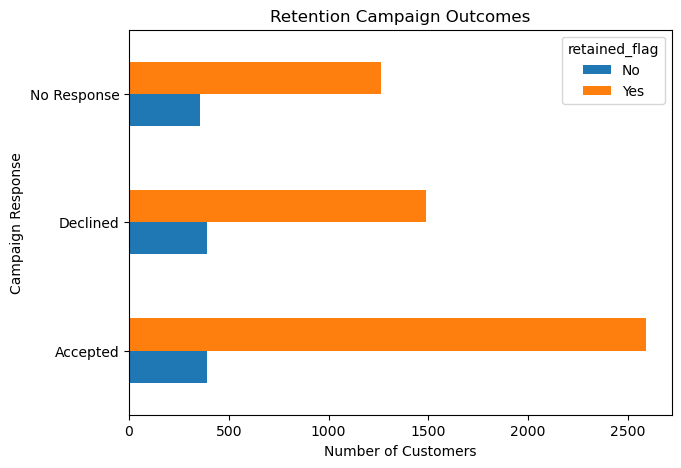

In [51]:
campaign_outcome = retention_campaigns.groupby(["response", "retained_flag"]).size().unstack()

campaign_outcome.plot(kind="barh", figsize=(7,5))

plt.title("Retention Campaign Outcomes")
plt.xlabel("Number of Customers")
plt.ylabel("Campaign Response")
plt.savefig("Chart10_Retention_Campaign_Outcomes.png", dpi=300, bbox_inches="tight")

## Observation

- Customers who **accepted** the retention campaign have the highest number of retained customers, indicating the campaign was most effective for this group.
- The **Declined** and **No Response** groups have comparatively fewer retained customers, although retained customers still outnumber non-retained customers in both categories.
- These findings suggest that encouraging customers to engage with retention campaigns can improve customer retention outcomes.